[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shanahdt/huji_summer_class_2026/blob/main/notebooks/day1_encoding.ipynb)


# Day 1: Encoding as Interpretation; Counting Things!
**Date:** Sunday 21 June 2026  


In [11]:
import os, subprocess

# Clone repo and set working directory
# Safe to run in both Colab and local Jupyter
repo_url = 'https://github.com/shanahdt/huji_summer_class_2026.git'
repo_name = 'huji_summer_class_2026'

# Check if we're already inside the repo (local), or need to clone (Colab)
if not os.path.exists('../data'):
    if not os.path.exists(f'/content/{repo_name}'):
        subprocess.run(['git', 'clone', repo_url], check=True)
    os.chdir(f'/content/{repo_name}/notebooks')
    print('Cloned and changed directory.')
else:
    print('Data directory found — running locally, no clone needed.')

Data directory found — running locally, no clone needed.



# Representing Musical Information

Music is a fairly difficult thing to represent. We can represent soundwaves, pitch, loudness, timbre, *etc.*, but those are just components of this thing that we call "music". We have to consider the sonic, the notated, and also broader aspects of structure (and logic).

In this class, we will be primarily looking at notated scores, which themselves are an abstraction of "the musical object." Even if we decide to begin with musical notation, however, we face some issues.

Let's take the "Happy Birthday" for example:

![Happy Birthday](../images/happy-birthday.png)

## With DARMS (1966–1980ish)

DARMs was a project in in the 1960s and 1970s, spearheaded by Stefan Bauer-Mengelberg. It was also called the Ford-Columbia encoding language, and was intended to make it affordable and manageable for anyone to have their own scores, and to be able to print them cheaply. It was also the hope that non-musicians would be able to encode scores, which would make the process more affordable to all. 

As such, notes were just encoded by a spatial point.

![The DARMS Grid](../images/darms_grid.png){width=50%}

So to encode something like "Happy Birthday" in DARMS, we might approach it something like this:

```
!G
!M3:4
20E.U 20SU / 21QU 20QU 23QU / 22QU 20E.U 20SU / 
21QU 20QU 24QU / 23HU 20E.U 20SU /
27QD 25QD 23QU / 22LQU 21LQU 19E.U 19SU /
25QD 23QU 24QU 23H.U //

```

There are a number of different codes and tags that can be included, ranging from key signatures to instruments to articulations. Rhythms are encoded as follows:

```
W whole 
H half 
Q quarter
E eighth 
S sixteenth 
T thirty-second 
X sixty-fourth 
Y 128th
Z 256th
```

As you can imagine, this can get a little cumbersome. Here's an example by Stephen Dydo using DARMS, with the input code below. Try to parse it as best you can:

![Dydo's DARMS Example](../images/dydo_darms_example.png)


## With MUSTRAN (1967–1980ish)

Here is what "Happy Birthday" would look like as encoded with MUSTRAN:

```
GS,K*F+,3=4,8D.,16D,/,4E,4D,4G,/,2*F,8D.,16D,/,
4E,4D,4A,/,2G,,8D.,16D,/,4D+,4B,4G,/,4*F,4E,8D.,16D,/,
4B,4G,4A,/,2H.G//,END

```

MUSTRAN was created with the goal of encoding non-Western musics, and was inherently extensible. Notice here how one can encode indeterminate pitches, breath marks, and microtones.

![MUSTRAN Example](../images/wenker_p497.png)

## Humdrum (1985–present-ish)

Here is how we might encode it in the commonly used kern format, for use with the [Humdrum Toolkit:](https://www.humdrum.org/)

```
!!!OTL: Happy Birthday
**kern
*M3/4
*G:
*k[f#]
L8.d
16dJ
=
4e
4d
4g
=
2f#
L8.d
16dJ
=
4e
4d
4a
=
2g
L8.d
16dJ
=
4dd
4b
4g
=
(4f#
4e)
L8.c
16cJ
=
4b
4g
4a
=
2g.
==
*-
```

Some points worth mentioning:

- There is a distinction between metadata and musical data (the exclamation marks serve as comments of sorts).
- Notice how pitches are given specific octaves: `d` is seperate from `dd` which is separate from `D`.
- Pitches are grouped with `L` and `J` to indicate beaming, and slurs are indicated with parentheses. 
- There are score-wide elements, such as the meter (`*M3/4`), and a key signature (`*k[f#]`).
- There is also a syntax for providing musical data that might not actually exist in the score. For example, with a key signature of one sharp, it could be G major, but it could also be in E minor. So an explicit mentioning of the key is helpful.
- Perhaps more abstractly, notice that this is a two dimensional score of sorts: every moment of time is a new line, meaning one can search by line to find specific instances. This is particularly useful with _polyphonic_ music.  

You can try this out at the [Verovio Humdrum Viewer Website](https://verovio.humdrum.org/)


## Quick kern reference

| Symbol | Meaning |
|--------|---------|
| `!!!` | Global metadata record |
| `**kern` | Spine type |
| `*M6/8` | Meter |
| `*G:` | Key of G |
| `4g` | Quarter note G4 |
| `gg` | G5 (repeated letter = octave up) |
| `=1` | Barline |
| `*-` | End of spine |


## Exercise: Encoding Audit

Pick one tune (this can be on the Verovio website if you'd like!). Read its kern file as plain text.

Identify **at least three encoding decisions** the kern file makes when translating from notation into kern.

It might be helpful to think of: (1) what musical information is *fixed*, and (2) what is *left out*?


# Counting Things Part 1: A Single Piece

## Metadata with a Kern File as Plain Text

Now that we've covered some of the ways music has been encoded, let's get some musical information. 

We can start by looking at metadata. In kern files, these are represented with a `!!!` tag for "global" comments (such as composer, year of composition, *etc.*), but other things like meter and time signature are indicated with an asterisk. 


In [54]:
### let's get the time signature in a kern file without music21. We can just look at the actual text files. 

with open('../data/happy_birthday.krn', 'r') as f:
    for line in f:
        if line.startswith('*M'):
            time_signature = line.strip()
            break
print(f"Time Signature: {time_signature}")


Time Signature: *M3/4


### What this code is doing

This cell reads a kern file as plain text and extracts the time signature line. It doesn't use music21 or any heavy libraries, but it's a bit limited.

Line by line:

1. `with open('../data/happy_birthday.krn', 'r') as f:`
   Opens the file in read mode and stores it in `f`.
   Using `with` automatically closes the file afterward.

2. `for line in f:`
   Loops through the file one line at a time.

3. `if line.startswith('*M'):`
   Checks whether the current line begins with `*M`.
   In kern notation, lines starting with `*M` store the meter/time-signature token.

4. `time_signature = line.strip()`
   Saves that line (after removing trailing whitespace/newlines) to a variable.

5. `break`
   Stops the loop immediately after finding the first matching time-signature line.

6. `print(f"Time Signature: {time_signature}")`
   Prints the result in a readable format.

Why this works:

- Kern files are text files, so metadata can be found by scanning line prefixes.
- `*M3/4`, `*M2/2`, etc. encode meter.
- If the file has multiple spines, you may see the same meter token repeated on the same line (for example, one token per spine).


In [34]:
### Exercise. Modify the code above to get the key signature in a kern file without music21. We can just look at the actual text files.




Key Signature: *k[f#]


## Metadata with music21

We can find the key signature and the time signature using the same file but with music21. 

In [40]:
from music21 import converter

score = converter.parse('../data/happy_birthday.krn')
key_signature = score.recurse().getElementsByClass('KeySignature')[0]
time_signature = score.recurse().getElementsByClass('TimeSignature')[0]

print(f"Key Signature: {key_signature}")
print(f"Time Signature: {time_signature}")

Key Signature: G major
Time Signature: <music21.meter.TimeSignature 3/4>


### What this music21 code is doing (step by step)

The version above uses the `music21` library to parse the score structure for us, instead of scanning raw text lines manually like we did before. 

Here are the steps:

1. `from music21 import converter`
   Imports the parser utility from music21.

2. `score = converter.parse('../data/happy_birthday.krn')`
   Reads the kern file and converts it into a structured score object.
   This is the key difference: we now have musical objects (notes, key, meter), not just strings.

3. `key_signature = score.recurse().getElementsByClass('KeySignature')[0]`
   Grabs the key signature from the text file.

4. `time_signature = score.recurse().getElementsByClass('TimeSignature')[0]`
   Walks through the score hierarchy, finds time-signature objects, and takes the first one.


5. `print(f"Key Signature: {key_signature}")`
   Prints the detected key in readable form.

6. `print(f"Time Signature: {time_signature}")`
   Prints the time signature found in the parsed score.



This seems a little more complicated, but it has its benefits!!!

Why this is often better than the plain-text version above:

- It is notation-aware: music21 understands score structure and musical classes. Without music21, Python is just treating it as a plain text file and has no music-specific knowledge or vocabulary.
- It is more flexible: you can immediately keep analyzing notes, chords, intervals, and parts from the same `score` object.
- It is less brittle: you do not depend on specific line prefixes like `*M` being found first in raw text.

Trade-off:

- It is heavier than text scanning (slower startup, extra dependency), so plain text can still be useful for quick metadata checks.

## Counting Pitches (with music21)

Now that we've explored the metadata, let's count some pitches!!

The code below counts the pitches in Happy Birthday.

In [55]:
# Get unique pitches
from music21 import converter, pitch, analysis
from collections import Counter

# Parse the kern file and extract all the pitches
score = converter.parse('../data/happy_birthday.krn')
all_pitches = score.pitches

# Count occurrences of each pitch
pitch_counter = Counter(str(p) for p in all_pitches)

# Print results and sort!
print("Pitch counts:")
for pitch_name, count in pitch_counter.most_common():
    print(f"{pitch_name}: {count}")

Pitch counts:
D4: 8
G4: 5
E4: 3
F#4: 2
A4: 2
B4: 2
C4: 2
D5: 1


### What this code is doing

Step by step:

Import the libraries! (This is a big thing in Python...)
1. `from music21 import converter, pitch, analysis` imports tools from `music21`, a library for working with musical scores in Python.
2. `from collections import Counter` imports a helper that counts repeated items automatically.

Turn the happy birthday file that we have into something that can be read by music21. 
3. `converter.parse('../data/happy_birthday.krn')` opens the kern file and turns it into a musical score object that Python can inspect.
4. `score.pitches` collects all pitches found in that score.
5. `Counter(str(p) for p in all_pitches)` converts each pitch to text such as `G4` or `F#4`, then counts how many times each one appears.
6. `pitch_counter.most_common()` sorts the results from most frequent to least frequent.

The for loop!
7. The `for` loop prints each pitch and its count in a readable way.

In plain language, this cell answers the question:

> Which notes happen most often in this melody?

Example output might look something like this:

```
Pitch counts:
G4: 5
D4: 4
A4: 3
```


### Exercise: Count Czech folksong pitches with music21

You can find a Czech folksong here: `../data/Essen/Czech/czech01.krn` (you can even find others with 02, 03, *etc.*). Can you count the pitches in one of these folksongs?

In [22]:
### your code here...



Pitch counts:
G4: 8
C5: 7
A4: 4
D5: 4
F4: 3
B4: 2
E5: 2


## Counting Scale Degrees with music21
This is a useful first analytical step, because it turns a symbolic score into something measurable and comparable!!

At the end of the day, however, this is only so helpful. It might be better if we could normalize by scale degree. 

Here's how we'd do that:

In [56]:
scale_degree_counter = Counter()

# parse the kern file
score = converter.parse('../data/happy_birthday.krn')

# figure out the key
pitch_count = analysis.discrete.KrumhanslKessler()
key = pitch_count.getSolution(score)

# count scale degrees for each note
for n in score.flatten().notes:
    scale_degree = key.getScaleDegreeFromPitch(n.pitch)
    scale_degree_counter[scale_degree] += 1

# print results
for scale_degree, count in scale_degree_counter.most_common():
    print(f"Scale Degree {scale_degree}: {count}")

Scale Degree 5: 9
Scale Degree 1: 5
Scale Degree 6: 3
Scale Degree 7: 2
Scale Degree 2: 2
Scale Degree 3: 2
Scale Degree 4: 2


### What this code is doing

This cell counts **scale degrees** instead of exact pitches.

Step by step:

1. `scale_degree_counter = Counter()` creates an empty counter that will store how many times each scale degree appears. The capital letters and the parentheses are instantiating a "class". We will come back to that later. 

We are setting up a few music21 things here, importing the file but also setting up it's key-finding algorithm:

2. `converter.parse('../data/happy_birthday.krn')` reads the kern file and turns it into a score object again.
3. `analysis.discrete.KrumhanslKessler()` creates a tool that tries to identify the key of the piece (**NB:** Using this is an analytical decision that shouldn't be taken lightly!)

4. `key = pitch_count.getSolution(score)` uses that tool to guess the key from the notes in the score.
5. `score.flatten().notes` gives a simple stream of the notes so we can loop through them one by one.
6. `key.getScaleDegreeFromPitch(n.pitch)` asks: in this key, what scale degree is this note? For example, if the key is G major, then `G` is scale degree 1 and `D` is scale degree.

Here we have counters and tallies!

7. `scale_degree_counter[scale_degree] += 1` adds one to the count for that scale degree.
8. `scale_degree_counter.most_common()` sorts the results from most frequent to least frequent.
9. The final `for` loop prints the results in a readable format.

This cell simply answers the question:

> Which scale steps are used most often in this melody?

Example output might look like this:

```
Scale Degree 5: 6
Scale Degree 1: 5
Scale Degree 2: 3
```


## A More Complicated Example (Chopin)

Let's look at all of the pitches in Chopin's E Minor *Prelude* (op. 28, no. 4). You'll see that life get's a little more difficult once we have multiple parts. 


In [57]:
scale_degree_counter = Counter()

# Let's get the E minor prelude. 
score = converter.parse('../data/humdrum_scores/Chopin/Preludes/prelude28-04.krn')

# extract the left hand part (usually the second part in a piano score)
left_hand = score.parts[0]

# figure out the key
pitch_count = analysis.discrete.KrumhanslKessler()
key = pitch_count.getSolution(left_hand)

# count scale degrees for each pitch in the left hand
for element in left_hand.flatten().notes:
    pitches = element.pitches if element.isChord else [element.pitch]
    for p in pitches:
        scale_degree = key.getScaleDegreeFromPitch(p)
        if scale_degree is not None:
            scale_degree_counter[scale_degree] += 1

# print results
for scale_degree, count in scale_degree_counter.most_common():
    print(f"Scale Degree {scale_degree}: {count}")

Scale Degree 1: 22
Scale Degree 4: 14
Scale Degree 5: 13
Scale Degree 3: 6
Scale Degree 6: 2
Scale Degree 7: 2


### What this code is doing...

This cell counts scale degrees in the left-hand part of Chopin's E minor Prelude.

The counter class and the conversion again...
1. `scale_degree_counter = Counter()` creates an empty counter that will store how many times each scale degree appears.
2. `score = converter.parse('../data/humdrum_scores/Chopin/Preludes/prelude28-04.krn')` opens the kern file and turns it into a music21 score object.
3. `left_hand = score.parts[0]` selects the left most column part in the score. In this file, that part is being treated as the left-hand staff. If it were `score.parts[1]` it would be the right hand in this instance.
4. `pitch_count = analysis.discrete.KrumhanslKessler()` creates a key-finding tool based on pitch frequency.
5. `key = pitch_count.getSolution(left_hand)` asks music21 to guess the most likely key for the left-hand part.
6. `for element in left_hand.flatten().notes:` loops through every note or chord in the left-hand part.
7. `pitches = element.pitches if element.isChord else [element.pitch]` checks whether the current item is a chord. If it is, the code gets every pitch inside it; otherwise it makes a one-item list containing the single pitch.
8. `for p in pitches:` loops through each pitch found in that note or chord.
9. `scale_degree = key.getScaleDegreeFromPitch(p)` converts that pitch into a scale degree in the guessed key.
10. `if scale_degree is not None:` skips pitches that do not fit cleanly into the key.
11. `scale_degree_counter[scale_degree] += 1` adds one to the count for that scale degree.
12. `for scale_degree, count in scale_degree_counter.most_common():` loops through the counts from most common to least common.
13. `print(f"Scale Degree {scale_degree}: {count}")` prints the final results in a readable format.

In short, the code is asking: which scale steps appear most often in this part, instead of which exact note names appear most often?

### Exercise (A Quick one!)

In the cell below, figure out the pitch count in the **right** hand!


In [ ]:
#Your code here...


# Counting Things Part 2: Lots of Pieces!

It's not that interesting to count things in a single piece. We use computers to count lots and lots of things in lots and lots of pieces. 

Let's start by taking the same Czech folksong corpus, and counting all of the scale degrees. 



In [58]:
from glob import glob

czech_folksongs = glob('../data/Essen/Czech/*.krn')
pitch_class_names = ['C', 'C#', 'D', 'Eb', 'E', 'F', 'F#', 'G', 'Ab', 'A', 'Bb', 'B']
pitch_class_counter = Counter({name: 0 for name in pitch_class_names})

for piece in czech_folksongs:
    score = converter.parse(piece)

    for element in score.recurse().notes:
        pitches = element.pitches if element.isChord else [element.pitch]
        for p in pitches:
            pitch_class_name = pitch_class_names[p.pitchClass]
            pitch_class_counter[pitch_class_name] += 1

pitch_class_table = [(name, pitch_class_counter[name]) for name in pitch_class_names]

for pitch_name, count in pitch_class_table:
    print(f"{pitch_name}: {count}")

C: 122
C#: 14
D: 246
Eb: 17
E: 126
F: 69
F#: 70
G: 232
Ab: 11
A: 222
Bb: 70
B: 147


### What this code is doing

This cell counts **pitch classes** across many Czech folksongs and prints all 12 pitch classes, even if some of them never appear.

The main idea is: load every `.krn` file in the folder, turn every note into one of the 12 pitch classes, count them across the whole corpus, and then print the full list in chromatic order.

Step by step:

1. `from glob import glob`
   Imports the `glob` tool so Python can find lots of files at once.

2. `czech_folksongs = glob('../data/Essen/Czech/*.krn')`
   Finds every kern file in the Czech corpus folder.

3. `pitch_class_names = ['C', 'C#', 'D', 'Eb', 'E', 'F', 'F#', 'G', 'Ab', 'A', 'Bb', 'B']`
   Creates a fixed list of the 12 pitch classes we want to report.

4. `pitch_class_counter = Counter({name: 0 for name in pitch_class_names})`
   Starts the counter with all 12 pitch classes already present.
   This is why even missing pitch classes will still print as `0`.

5. `for piece in czech_folksongs:`
   Loops through the folksongs one by one.

6. `score = converter.parse(piece)`
   Reads one kern file into a music21 score object.

7. `for element in score.recurse().notes:`
   Loops through the notes in that score.

8. `pitches = element.pitches if element.isChord else [element.pitch]`
   Handles both single notes and chords.
   If the element is a chord, the code counts every pitch inside it.

9. `pitch_class_name = pitch_class_names[p.pitchClass]`
   Converts a pitch into a pitch-class label such as `C`, `F#`, or `Bb`.

10. `pitch_class_counter[pitch_class_name] += 1`
   Adds one to that pitch class's total count.

11. `pitch_class_table = [(name, pitch_class_counter[name]) for name in pitch_class_names]`
   Builds the final table in a fixed order from `C` through `B`.

12. `for pitch_name, count in pitch_class_table:`
   Loops through the final table.

13. `print(f"{pitch_name}: {count}")`
   Prints every pitch class and its total, including zeros.

In plain language, this code answers the question:

> Across all of these Czech folksongs, how often does each of the 12 pitch classes appear?

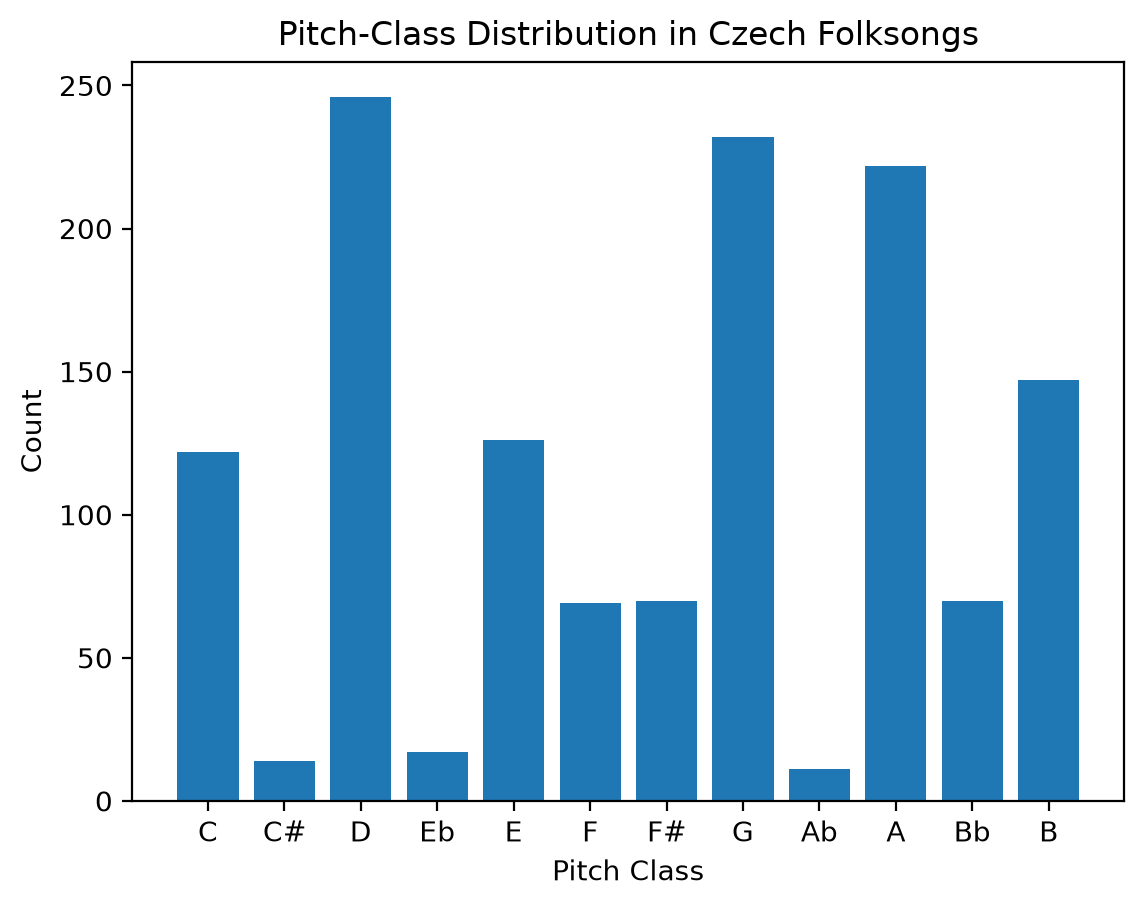

In [59]:
## We can use another library like matplotlib to visualize the pitch-class distribution

import matplotlib.pyplot as plt

pitch_names, counts = zip(*pitch_class_table)
plt.bar(pitch_names, counts)
plt.xlabel('Pitch Class')
plt.ylabel('Count')
plt.title('Pitch-Class Distribution in Czech Folksongs')
plt.show()

### What this code is doing

This cell takes the pitch-class counts we already calculated and turns them into a bar chart.

Step by step:

1. `import matplotlib.pyplot as plt`
   Imports the plotting library and gives it the short name `plt`.
   `matplotlib` is one of the most common Python libraries for making graphs.

2. `pitch_names, counts = zip(*pitch_class_table)`
   This line splits the table into two separate pieces.
   `pitch_class_table` looks like a list of pairs such as `('C', 122)` or `('D', 246)`.
   The `*` unpacks that list so `zip` can look at all the pairs one column at a time.
   Then `zip(...)` groups together:

   - all the pitch names in one tuple
   - all the counts in another tuple

   So after this line:

   - `pitch_names` is something like `('C', 'C#', 'D', ...)`
   - `counts` is something like `(122, 14, 246, ...)`

   This is useful because plotting functions usually want one list for the x-axis labels and one list for the y-axis values.

3. `plt.bar(pitch_names, counts)`
   Creates a bar chart.
   The first argument gives the labels along the horizontal axis, and the second argument gives the bar heights.

4. `plt.xlabel('Pitch Class')`
   Labels the x-axis.
   `xlabel` means “x-axis label.”
   Here it tells the reader that the horizontal axis shows pitch-class names.

5. `plt.ylabel('Count')`
   Labels the y-axis.
   `ylabel` means “y-axis label.”
   Here it tells the reader that the vertical axis shows how many times each pitch class appeared.

6. `plt.title('Pitch-Class Distribution in Czech Folksongs')`
   Adds a title at the top of the graph so the reader knows what the chart shows.

7. `plt.show()`
   Displays the finished graph in the notebook output.
   Without this line, the plot might not appear clearly in some notebook environments.

In plain language, this code says: take the pitch-class totals, put the names along the bottom, put the counts on the side, and draw bars so we can compare them visually.

## Exercise: 

In [67]:
chromatic_degree_labels = ['1', 'b2', '2', '#2/b3', '3', '4', '#4/b5', '5', '#5/b6', '6', 'b7', '7']
chromatic_degree_counter = Counter({label: 0 for label in chromatic_degree_labels})

for piece in czech_folksongs:
    score = converter.parse(piece)
    pitch_count = analysis.discrete.KrumhanslKessler()
    key = pitch_count.getSolution(score)

    for element in score.recurse().notes:
        pitches = element.pitches if element.isChord else [element.pitch]
        for p in pitches:
            semitone_distance = (p.pitchClass - key.tonic.pitchClass) % 12
            degree_label = chromatic_degree_labels[semitone_distance]
            chromatic_degree_counter[degree_label] += 1

chromatic_degree_table = [(label, chromatic_degree_counter[label]) for label in chromatic_degree_labels]

for degree_label, count in chromatic_degree_table:
    print(f"Scale Degree {degree_label}: {count}")


Scale Degree 1: 312
Scale Degree b2: 23
Scale Degree 2: 162
Scale Degree #2/b3: 85
Scale Degree 3: 124
Scale Degree 4: 158
Scale Degree #4/b5: 0
Scale Degree 5: 247
Scale Degree #5/b6: 26
Scale Degree 6: 106
Scale Degree b7: 50
Scale Degree 7: 53


### What this chromatic scale-degree code is doing

This version goes beyond the seven diatonic scale degrees.
Instead of only counting `1` through `7`, it counts all 12 pitch positions relative to each piece's tonic.

That means it can also capture altered or non-diatonic notes such as `b2`, `b3`, `#4`, `b6`, and `b7`.

Step by step:

1. `chromatic_degree_labels = ['1', 'b2', '2', 'b3', '3', '4', '#4', '5', 'b6', '6', 'b7', '7']`
   Creates labels for the 12 semitone positions above the tonic.

2. `chromatic_degree_counter = Counter({label: 0 for label in chromatic_degree_labels})`
   Starts the counter with all 12 categories already present, so every label will print even if its count is `0`.

3. `key = pitch_count.getSolution(score)`
   Estimates the key of each folksong so the tonic can be used as the reference point.

4. `semitone_distance = (p.pitchClass - key.tonic.pitchClass) % 12`
   Measures how far a note is from the tonic in semitones.
   For example, if the tonic is `G`, then `G` is distance `0`, `Ab` is distance `1`, `A` is distance `2`, and so on.

5. `degree_label = chromatic_degree_labels[semitone_distance]`
   Converts that semitone distance into a scale-degree label like `1`, `b3`, or `#4`.

6. `chromatic_degree_counter[degree_label] += 1`
   Adds one to that category's total count.

In plain language, this code asks: relative to each song's tonic, how often does each of the 12 chromatic pitch positions occur across the whole corpus?

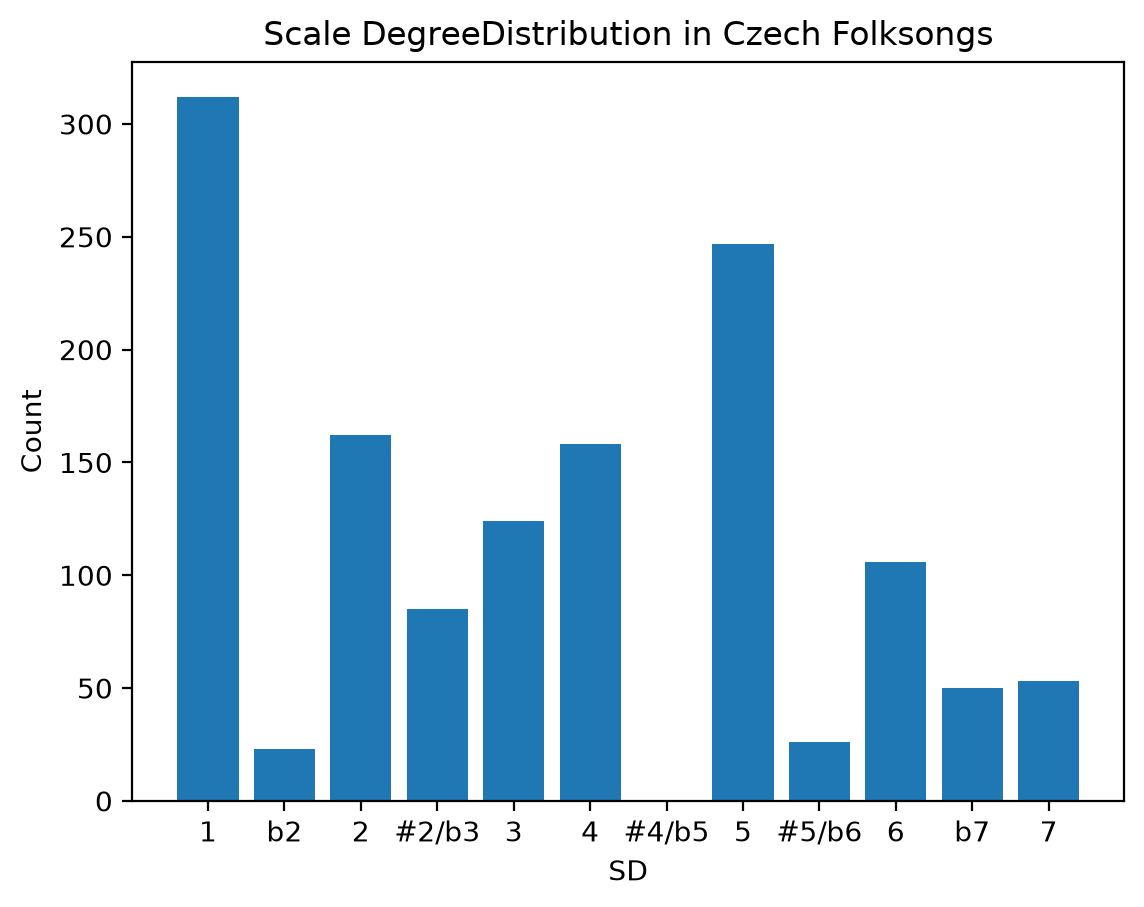

In [84]:
## We can use another library like matplotlib to visualize the pitch-class distribution

import matplotlib.pyplot as plt

degree_label, counts = zip(*chromatic_degree_table)
plt.bar(degree_label, counts)
plt.xlabel('SD')
plt.ylabel('Count')
plt.title('Scale DegreeDistribution in Czech Folksongs')
plt.show()

## Functions

This is a lot of verbose code! We don't need to always be saying the same thing over and over again, and in fact, it's better code to try to repeat things as rarely as possible. We can come up with a `function` to help with this.

In Python a function is `defined` with `def` followed by the name we want to use, and then an `argument` name. So for my purposes, I want to count and plot scale degrees (`count_and_plot_scale_degrees`) of different folders (so I have a `folder_path` argument.)

In [ ]:
### I'm defining my function with an argument!
def count_and_plot_scale_degrees(folder_path):
    # this is all the code from before, and now it's wrapped into a function that takes a folder path as an argument.
    chromatic_degree_labels = ['1', 'b2', '2', '#2/b3', '3', '4', '#4/b5', '5', '#5/b6', '6', 'b7', '7']
    chromatic_degree_counter = Counter({label: 0 for label in chromatic_degree_labels})

    # Get all kern files in the selected Essen subfolder
    files = glob(f"{folder_path}/*.krn")
    ## this is just to keep the code from breaking if there are no kern files...
    if not files:
        print(f"No .krn files found in: {folder_path}")
        return

    ## here's my for loop!!!! It's going over each piece, converting it, 
    ## running the key-finding algorithm, and then counting the scale degrees.
    for piece in files:
        score = converter.parse(piece)
        pitch_count = analysis.discrete.KrumhanslKessler()
        key = pitch_count.getSolution(score)


        ## now I'm going to go through each note in the score and count its scale degree relative to the key.
        ## this is messy code; just bear with me.
        for element in score.recurse().notes:
            pitches = element.pitches if element.isChord else [element.pitch]
            for p in pitches:
                semitone_distance = (p.pitchClass - key.tonic.pitchClass) % 12
                degree_label = chromatic_degree_labels[semitone_distance]
                chromatic_degree_counter[degree_label] += 1

    chromatic_degree_table = [(label, chromatic_degree_counter[label]) for label in chromatic_degree_labels]

    # for degree_label, count in chromatic_degree_table:
    #     print(f"Scale Degree {degree_label}: {count}")


    ## here are the plotting functions.
    degree_labels, counts = zip(*chromatic_degree_table)
    plt.bar(degree_labels, counts)
    plt.xlabel('SD')
    plt.ylabel('Count')
    ## i would probably make this prettier before publication...
    plt.title(f'Scale Degree Distribution in {folder_path}')
    plt.show()

  



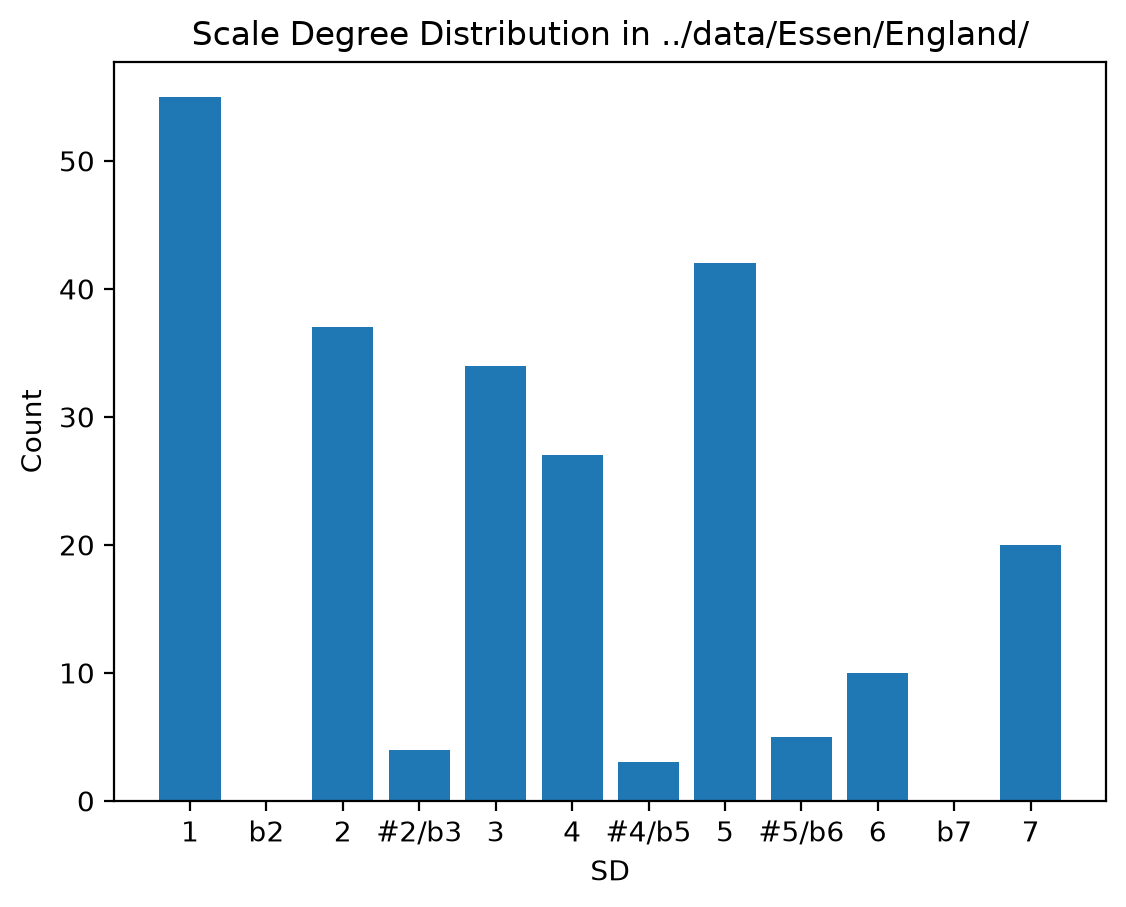

humdrum.spineParser: WARNING: Error in parsing event ('*MX') at line 13 for spine None: Incorrect meter: *MX found


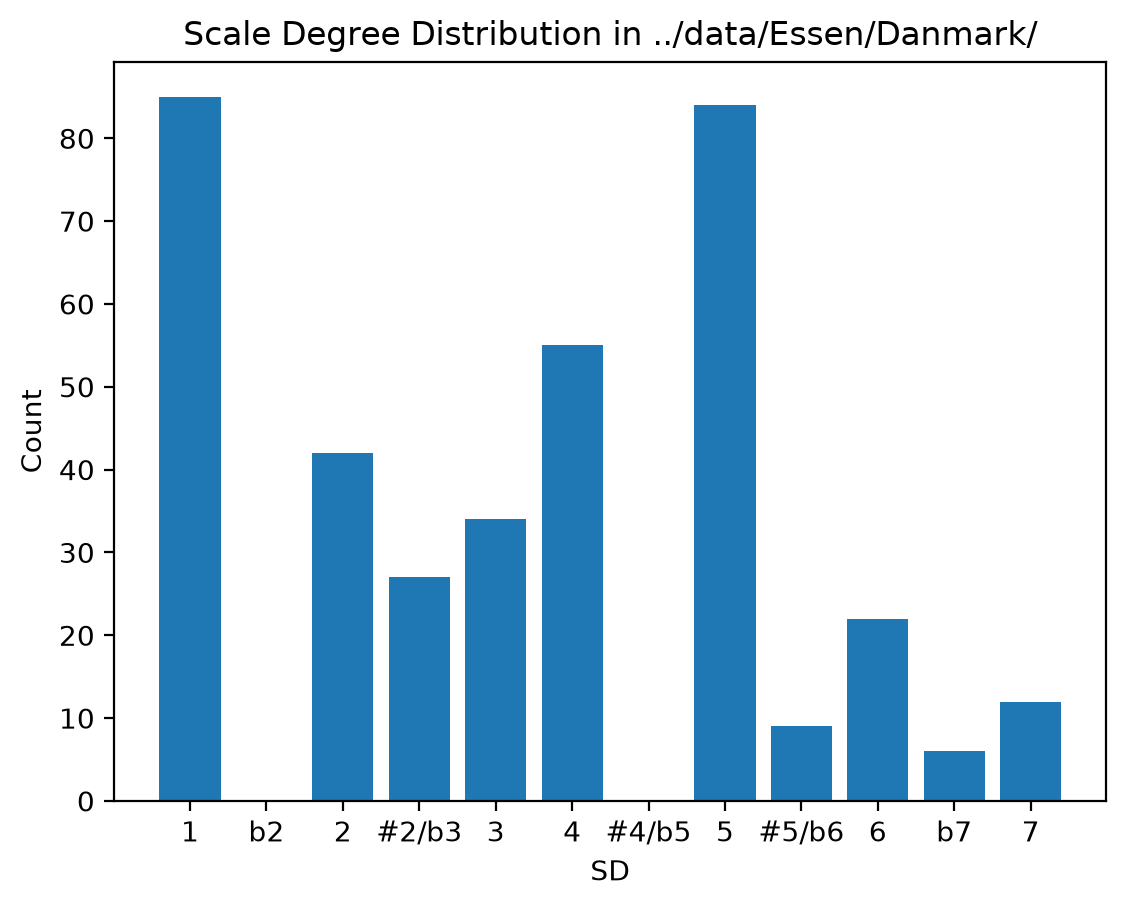

In [83]:
count_and_plot_scale_degrees('../data/Essen/England/')
count_and_plot_scale_degrees('../data/Essen/Danmark/')


## Exercise: Comparing Pitch-Class Distributions

Use my function to compare five of the following:

- [Elsass](../data/Essen/Elsass)
- [England](../data/Essen/England)
- [France](../data/Essen/France)
- [Italia](../data/Essen/Italia)
- [Jugoslav](../data/Essen/Jugoslav)
- [Luxembrg](../data/Essen/Luxembrg)
- [Magyar](../data/Essen/Magyar)
- [Misc](../data/Essen/Misc)
- [Nederlan](../data/Essen/Nederlan)
- [Oesterrh](../data/Essen/Oesterrh)
- [Polska](../data/Essen/Polska)
- [Romania](../data/Essen/Romania)
- [Rossiya](../data/Essen/Rossiya)
- [Schweiz](../data/Essen/Schweiz)
- [Sverige](../data/Essen/Sverige)
- [Tirol](../data/Essen/Tirol)
- [Ukraina](../data/Essen/Ukraina)

## From Counting to Testing

So far we've been *describing* distributions — counting scale degrees and 
plotting them. But description raises a question:

> When two distributions look different, how do we know if the difference 
> is meaningful, or just noise from having a limited sample?

Compare England vs. Polska. The plots look different. But:
- Maybe England just happens to have fewer pieces in the corpus
- Maybe the differences are real but small
- Maybe the differences are large and systematic

**Hypothesis testing** gives us a framework for figuring out how might be try to think of more objective ways of testing our theories.
The key idea: assume the two distributions are *the same* (the null hypothesis),
then ask how surprising our observed difference would be under that assumption.
If it's very surprising, we reject the null.

## The Chi-Squared Test!!!! (dun, Dun, DUN!!!)

![Chi-Squared](../images/chi2.png)

This seems daunting, but basically, it is saying:

1. what are we expecting to see?
2. what do we actually see?
3. Are these two numbers significantly different?

In the olden days, folks would take this number, and then go to a look up table in which they found their degrees of freedom (their n - 2) and then checked to see if that number created a p-value that was less than what they were hoping it would be. Now computers do that for us.

So basically, we assume that each scale degree would be roughly the same percentage if there was no difference and we create a big table for this, called a contingency table. 


In [2]:
# We need to compare two distributions as a contingency table
# Each row = a region, each column = a scale degree
# Each cell = how many times that scale degree appeared in that region

from glob import glob
from collections import Counter
from music21 import converter, analysis
import pandas as pd
import numpy as np

chromatic_degree_labels = ['1','b2','2','#2/b3','3','4','#4/b5','5','#5/b6','6','b7','7']

def get_degree_counts(folder_path):
    """Return a Counter of chromatic scale degrees for all kern files in folder."""
    counter = Counter({label: 0 for label in chromatic_degree_labels})
    for piece in glob(f"{folder_path}/*.krn"):
        score = converter.parse(piece)
        pitch_count = analysis.discrete.KrumhanslKessler()
        key = pitch_count.getSolution(score)
        for element in score.recurse().notes:
            pitches = element.pitches if element.isChord else [element.pitch]
            for p in pitches:
                dist = (p.pitchClass - key.tonic.pitchClass) % 12
                counter[chromatic_degree_labels[dist]] += 1
    return counter

# Get counts for two regions
england_counts = get_degree_counts('../data/Essen/England')
polska_counts   = get_degree_counts('../data/Essen/Polska')

# Build a DataFrame — one row per region, one column per scale degree
contingency = pd.DataFrame([england_counts, polska_counts],
                            index=['England', 'Polska'])[chromatic_degree_labels]
print(contingency)

           1  b2    2  #2/b3   3    4  #4/b5    5  #5/b6   6  b7   7
England   55   0   37      4  34   27      3   42      5  10   0  20
Polska   206   0  130     75  81  112      0  204     24  44  23  18


### What is a contingency table?

A contingency table counts how often two categorical variables co-occur.
Here our two variables are:

- **Region** (England or Polska) — the rows
- **Scale degree** (1, b2, 2 ... 7) — the columns

Each cell answers: "how many times did scale degree X appear in region Y?"

The chi-square test asks: **if region had no effect on scale degree distribution,
what would we expect these counts to look like?** Then it measures how far 
our actual counts deviate from that expectation.

The expected count for any cell is simply:
$$E_{ij} = \frac{(\text{row total}_i) \times (\text{column total}_j)}{\text{grand total}}$$

Large deviations from expected → small p-value → evidence that region
*does* affect scale degree distribution.

In [8]:
from scipy.stats import chi2_contingency

# Remove rows/columns with total count = 0 (chi-square cannot use them)
contingency = contingency.loc[
    contingency.sum(axis=1) > 0,
    contingency.sum(axis=0) > 0
]

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p:.4f}")
print()

if p < 0.05:
    print("The distributions are significantly different (p < 0.05).")
    print("The scale degree profiles of England and Polska are unlikely")
    print("to be this different by chance alone.")
else:
    print("No significant difference detected (p >= 0.05).")
    print("It is basically at chance levels of differentiation.")

Chi-square statistic: 61.43
Degrees of freedom:   10
p-value:              0.0000

The distributions are significantly different (p < 0.05).
The scale degree profiles of England and Polska are unlikely
to be this different by chance alone.


### Interpreting the result carefully

A significant chi-square tells you the two distributions are *statistically* 
different. It does **not** tell you:

- **Where** the difference is (which scale degrees drive it)
- **Why** it exists (mode differences? melodic style? corpus size?)
- **Whether** it's musically meaningful — statistical significance and 
  musical significance are not the same thing

A corpus with thousands of notes will produce significant results for 
tiny differences. A corpus with 50 notes might miss large ones.

To see *where* the differences are, look at the residuals:

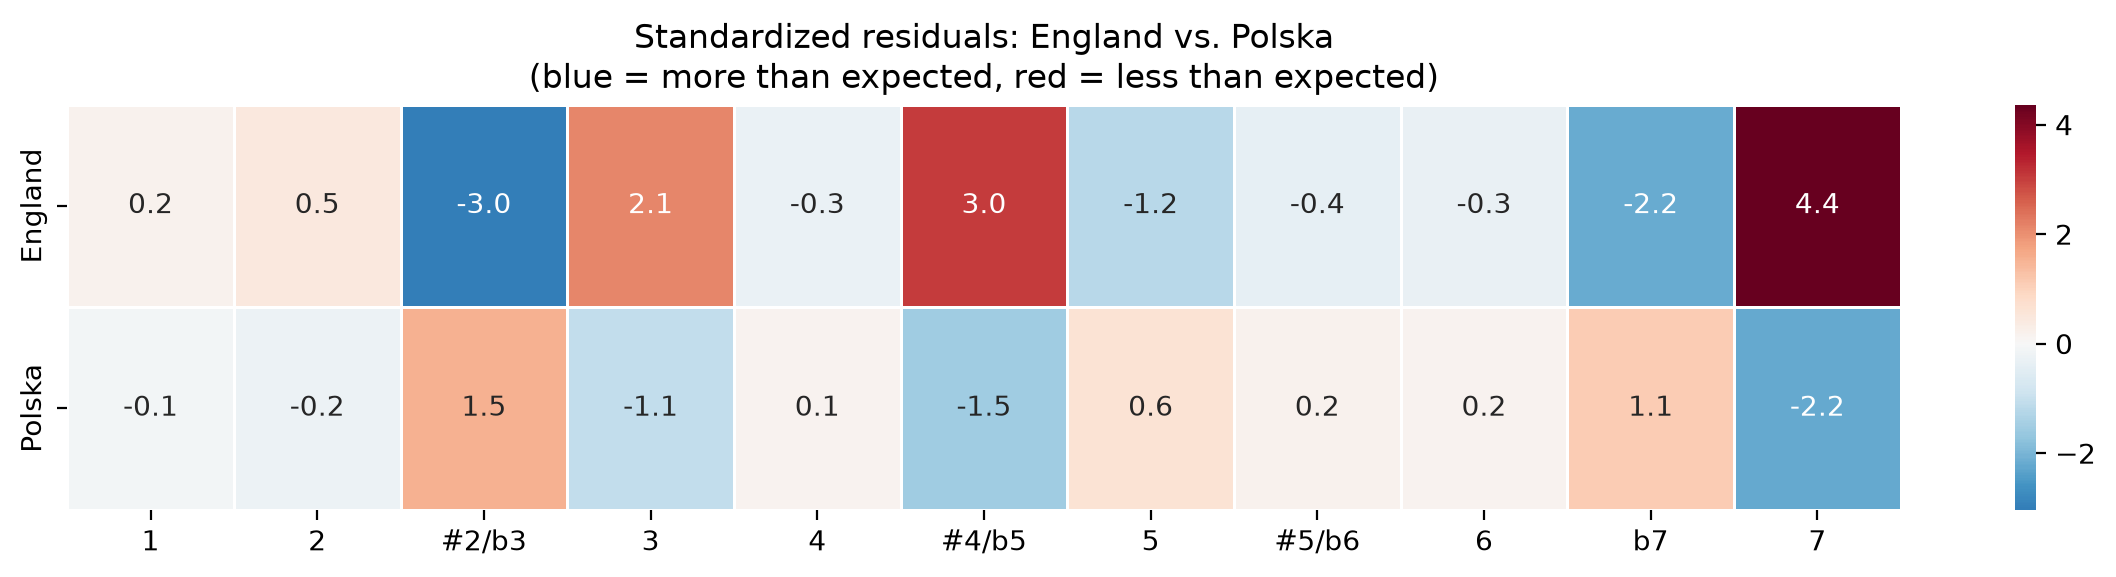

In [9]:
# Standardized residuals — large values tell you which cells 
# contribute most to the chi-square statistic
expected_df = pd.DataFrame(expected, 
                            index=contingency.index,
                            columns=contingency.columns)
residuals = (contingency - expected_df) / np.sqrt(expected_df)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(residuals, annot=True, fmt='.1f', center=0,
            cmap='RdBu_r', ax=ax, linewidths=0.5)
ax.set_title('Standardized residuals: England vs. Polska\n'
             '(blue = more than expected, red = less than expected)')
plt.tight_layout()
plt.show()

### What residuals are

These values show how far each cell is from the value we would expect if the two regions had the same scale-degree distribution.

Step by step:

1. `expected_df` stores the expected counts from the chi-square test.
   These are the counts the table would have if region and scale degree were unrelated.

2. `residuals = (contingency - expected_df) / np.sqrt(expected_df)`
   This compares the observed counts to the expected counts.
   - Positive values mean we observed **more** than expected.
   - Negative values mean we observed **less** than expected.
   - Values near `0` mean observed and expected are very similar.

3. The heatmap colors help us read those differences quickly.
   - Blue means more than expected.
   - Red means less than expected.
   - White or pale colors mean close to expected.

In plain language, residuals tell us **where** the chi-square difference is coming from, not just whether the two regions are different overall.

## Exercise: Test your own comparison

Pick two regions from the Essen collection and run a chi-square test.

1. Build the contingency table using `get_degree_counts()`
2. Run `chi2_contingency()`
3. Plot the residuals
4. Write 3–4 sentences: what does the significant (or non-significant) 
   result tell you, and what *doesn't* it tell you?

**Harder version:** Test more than two regions at once by adding more rows
to the contingency table. What happens to your degrees of freedom?

In [ ]:
## your code here!!!!

```{admonition} Concept check!
:class: tip

The first quizzes for today are simply for self-assessment. It might be good to answer these first before executing any of the code below. 

Questions open in a new tab!

**[→ Open Day 1 Quiz](../quizpages/day1_quiz.md)**
```



## Project Log — Entry 1

Please email tonight with the following:

- *My corpus is [X — it could also be a subset: mode / genre / region / instrument].*  (note the datasets above that we have available! Let me know if you'd like to go beyond these).
- *My research question is [Y].*  
- *I expect to find that [Z] because [musical or theoretical reasoning].*  

*(Write here — 100–150 words)*


## Tomorrow: Day 2 (Monday 22 Jun)

Tomorrow we will be discussing notes moving to one another (n-grams), and we will build our own tools for this.

- Don't forget to email me to chat projects!
- Please take the quiz when you get a chance!


